# Case 2 — Crypto Signal Universe

**Hypothesis.** On Binance USDT-margined perpetuals (top-10 by liquidity), at least one of *funding-rate carry*, *perp-spot basis*, or *price-only momentum* carries cross-sectional edge that survives `CRYPTO_PERP_WITH_FUNDING` costs (4+2 bps round-trip plus dynamic funding payments).

**Why this case is the most novel.** The retail-quant world claims funding-rate edges are real but well-known papers (Schmeling-Schrimpf-Todorov, BIS WP 1087, 2023; Liu-Tsyvinski-Wu 2022) document that the basic delta-neutral cash-and-carry trade has compressed dramatically post-2024 as arb capital arrived. There is no rigorous public study of the *cross-sectional* spec on the top-10 daily-perp universe at this exact methodological level. This case fills that gap.

**Five feature families tested through the same GBM workhorse:**

1. **Returns-only baseline** — momentum + RSI + MACD + cross-sectional ranks (the Case 1-style price features).
2. **Funding-rate level + change** — per-symbol level, 1d and 7d Δ.
3. **Cross-sectional funding-rate carry rank** — long bottom-decile funding (cheap to long), short top-decile (cheap to short). The literature-supported spec.
4. **Perp-spot basis** — `premiumIndexKlines` close, normalised cross-sectionally.
5. **Union of all four** — let the model pick.

Each family uses the v0.2 harness: walk-forward + DSR sensitivity + stationary-block bootstrap CI + PBO + per-regime breakdown + `CRYPTO_PERP_WITH_FUNDING` (the funding payment is now a *cost*, not just a feature, completing the carry-trade economics).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
load_dotenv(ROOT / '.env', override=True)

from backtester.data.binance import (
    fetch_klines, fetch_funding_rate, fetch_premium_index_klines,
)
from backtester.features import (
    rolling_volatility, rsi, macd, momentum_rank, vol_rank, funding_features,
)
from backtester.eval.statistics import (
    annualised_sharpe, bootstrap_ci, dsr_sensitivity,
)
from backtester.eval.costs import CRYPTO_PERP_WITH_FUNDING, BPS
from backtester.eval.regimes import trend_regimes, per_regime_metrics
from backtester.eval.pbo import probability_of_backtest_overfitting
from backtester.portfolio import long_short_quantile_weights
from backtester.models import GBMClassifier
from backtester.eval import walk_forward_splits

pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True})
RNG = np.random.default_rng(42)

SYMBOLS = [
    'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT',
    'DOGEUSDT', 'ADAUSDT', 'AVAXUSDT', 'LINKUSDT', 'MATICUSDT',
]
START = '2021-01-01'
END = '2024-12-31'
LABEL_HORIZON = 1
TOP_BOTTOM_QUANTILE = 0.2
N_SPLITS = 5
EMBARGO = 5
MAX_BARS = 1500

## 1. Pull klines + funding + basis

Each loader paginates and caches by date. Funding-rate prints arrive every 8h; we resample to daily totals (3 prints summed) before lagging by one trading day.

In [2]:
def fetch_paginated_klines(symbol: str) -> pd.DataFrame:
    chunks = []
    cursor = pd.Timestamp(START, tz='UTC')
    end_ts = pd.Timestamp(END, tz='UTC')
    while cursor < end_ts and sum(c.shape[0] for c in chunks) < MAX_BARS:
        chunk = fetch_klines(symbol, interval='1d', market='futures',
                              start=cursor.isoformat(), end=end_ts.isoformat())
        if chunk.empty:
            break
        chunks.append(chunk)
        new_cursor = chunk.index.max() + pd.Timedelta(days=1)
        if new_cursor <= cursor:
            break
        cursor = new_cursor
        if chunk.shape[0] < 1000:
            break
    if not chunks:
        return pd.DataFrame()
    out = pd.concat(chunks).sort_index()
    return out[~out.index.duplicated(keep='first')]

klines, fundings, premia = {}, {}, {}
for sym in SYMBOLS:
    try:
        k = fetch_paginated_klines(sym)
        if not k.empty:
            klines[sym] = k
    except Exception as exc:
        print(f'klines {sym}: {exc}')
    try:
        fr = fetch_funding_rate(sym, start=START, end=END)
        if not fr.empty:
            fundings[sym] = fr['funding_rate']
    except Exception as exc:
        print(f'funding {sym}: {exc}')
    try:
        pr = fetch_premium_index_klines(sym, interval='1d', start=START, end=END)
        if not pr.empty:
            premia[sym] = pr['premium']
    except Exception as exc:
        print(f'premium {sym}: {exc}')

px = pd.DataFrame({s: k['close'] for s, k in klines.items()}).sort_index()
px.index = pd.DatetimeIndex(px.index).tz_localize(None)
print(f'Klines: {px.shape[1]} symbols × {px.shape[0]} bars')
print(f'Funding loaded for: {len(fundings)} symbols')
print(f'Premium loaded for: {len(premia)} symbols')

Klines: 10 symbols × 1461 bars
Funding loaded for: 10 symbols
Premium loaded for: 10 symbols


## 2. Build the five feature families

In [3]:
rets = px.pct_change(fill_method=None)
log_rets = np.log(px).diff()

# ----- Family 1: returns-only -----
tech_blocks = []
for sym in px.columns:
    s = px[sym]
    block = pd.DataFrame({
        'ret_1':     s.pct_change(1, fill_method=None),
        'mom_5':     s.pct_change(5, fill_method=None),
        'mom_20':    s.pct_change(20, fill_method=None),
        'vol_20':    rolling_volatility(log_rets[sym], window=20, annualise=365),
        'rsi_14':    rsi(s, period=14),
        'macd_line': macd(s)['macd_line'],
    })
    block['ticker'] = sym
    block.index.name = 'datetime'
    tech_blocks.append(block.reset_index())
tech_long = pd.concat(tech_blocks, ignore_index=True).set_index(['datetime', 'ticker']).sort_index()
tech_long['mom_rank'] = momentum_rank(px, lookback=63, skip=10).stack().reindex(tech_long.index).values
tech_long['vol_rank'] = vol_rank(rets, window=30).stack().reindex(tech_long.index).values
FAM_RETURNS = ['ret_1', 'mom_5', 'mom_20', 'vol_20', 'rsi_14', 'macd_line', 'mom_rank', 'vol_rank']

# ----- Family 2: funding-rate level + change -----
funding_blocks = []
for sym, fr in fundings.items():
    feat = funding_features(fr, calendar=px.index)
    feat['ticker'] = sym
    feat.index.name = 'datetime'
    funding_blocks.append(feat.reset_index())
funding_long = pd.concat(funding_blocks, ignore_index=True).set_index(['datetime', 'ticker']).sort_index() if funding_blocks else pd.DataFrame()
FAM_FUNDING = list(funding_long.columns) if not funding_long.empty else []

# ----- Family 3: cross-sectional funding carry rank -----
if not funding_long.empty:
    funding_level_wide = funding_long['funding_level'].unstack('ticker')
    # Cross-sectional rank on the lagged daily-aggregated funding.
    funding_carry_rank = funding_level_wide.rank(axis=1, pct=True)
    carry_rank_long = funding_carry_rank.stack().rename('funding_carry_rank')
    carry_rank_long.index.names = ['datetime', 'ticker']
else:
    carry_rank_long = pd.Series(dtype=float, name='funding_carry_rank')
FAM_CARRY = ['funding_carry_rank']

# ----- Family 4: perp-spot basis -----
premia_blocks = []
for sym, pr in premia.items():
    pr = pr.copy()
    pr.index = pd.DatetimeIndex(pd.to_datetime(pr.index, utc=True, errors='coerce')).tz_convert(None).normalize()
    pr = pr[~pr.index.duplicated(keep='last')]
    feat = pd.DataFrame({
        'basis_level': pr,
        'basis_change_5d': pr - pr.shift(5),
    }).reindex(px.index, method='ffill')
    # Lag by one day to prevent same-day leakage.
    feat = feat.shift(1)
    feat['ticker'] = sym
    feat.index.name = 'datetime'
    premia_blocks.append(feat.reset_index())
basis_long = pd.concat(premia_blocks, ignore_index=True).set_index(['datetime', 'ticker']).sort_index() if premia_blocks else pd.DataFrame()
if not basis_long.empty:
    basis_rank = basis_long['basis_level'].unstack('ticker').rank(axis=1, pct=True)
    basis_long['basis_rank'] = basis_rank.stack().reindex(basis_long.index).values
FAM_BASIS = list(basis_long.columns) if not basis_long.empty else []

# ----- Family 5: union -----
panel = tech_long.copy()
if not funding_long.empty:
    panel = panel.join(funding_long, how='left')
if not carry_rank_long.empty:
    panel = panel.join(carry_rank_long, how='left')
if not basis_long.empty:
    panel = panel.join(basis_long, how='left')
FAM_UNION = list(panel.columns)

panel = panel.dropna()
print(f'Panel rows after dropna: {len(panel):,}')
print(f'Family sizes: returns={len(FAM_RETURNS)}, funding={len(FAM_FUNDING)}, '
      f'carry={len(FAM_CARRY)}, basis={len(FAM_BASIS)}, union={len(FAM_UNION)}')

Panel rows after dropna: 13,769
Family sizes: returns=8, funding=3, carry=1, basis=3, union=15


## 3. Build labels

In [4]:
fwd_ret = px.pct_change(LABEL_HORIZON, fill_method=None).shift(-LABEL_HORIZON)
fwd_long = fwd_ret.stack().rename('fwd_ret')
fwd_long.index.names = ['datetime', 'ticker']
y_long = (fwd_long > 0).astype(int).rename('y')

design = panel.join(y_long, how='inner').join(fwd_long, how='inner').dropna()
print(f'Design rows: {len(design):,}')

Design rows: 13,759


## 4. Walk-forward across the 5 feature families (workhorse GBM)

In [5]:
FAMILIES = {
    'returns': [c for c in FAM_RETURNS if c in design.columns],
    'funding': [c for c in FAM_FUNDING if c in design.columns],
    'carry':   [c for c in FAM_CARRY  if c in design.columns],
    'basis':   [c for c in FAM_BASIS  if c in design.columns],
    'union':   [c for c in FAM_UNION  if c in design.columns and c != 'fwd_ret' and c != 'y'],
}
FAMILIES = {k: v for k, v in FAMILIES.items() if v}
print('Family feature counts:', {k: len(v) for k, v in FAMILIES.items()})

dates = design.index.get_level_values('datetime').unique().sort_values()
splits = list(walk_forward_splits(
    n=len(dates), n_splits=N_SPLITS,
    label_horizon=LABEL_HORIZON, embargo=EMBARGO,
))
y_full = design['y']
preds = {fam: pd.Series(np.nan, index=design.index, dtype=float) for fam in FAMILIES}

for i, (train_di, test_di) in enumerate(splits, 1):
    train_dates = dates[train_di]; test_dates = dates[test_di]
    train_mask = design.index.get_level_values('datetime').isin(train_dates)
    test_mask = design.index.get_level_values('datetime').isin(test_dates)
    if train_mask.sum() < 1000 or test_mask.sum() < 100:
        continue
    for fam, cols in FAMILIES.items():
        X = design[cols]
        model = GBMClassifier()
        model.fit(X[train_mask], y_full[train_mask])
        preds[fam][test_mask] = model.predict_proba(X[test_mask])
    print(f'Fold {i}: {test_dates.min().date()} → {test_dates.max().date()} '
          f'(train {train_mask.sum():,}, test {test_mask.sum():,})')

preds = {fam: s.dropna() for fam, s in preds.items()}

Family feature counts: {'returns': 8, 'funding': 3, 'carry': 1, 'basis': 3, 'union': 15}


Fold 1: 2021-11-01 → 2022-06-19 (train 2,310, test 2,310)


Fold 2: 2022-06-25 → 2023-02-05 (train 4,670, test 2,260)


Fold 3: 2023-02-11 → 2023-09-24 (train 6,980, test 2,260)


Fold 4: 2023-09-30 → 2024-05-12 (train 9,290, test 2,260)


Fold 5: 2024-05-18 → 2024-12-30 (train 11,600, test 2,159)


## 5. Build long/short portfolios per family with `CRYPTO_PERP_WITH_FUNDING`

The funding payment is now a *cost*, applied dynamically per ticker per day (longs pay positive funding; shorts receive). This is the cost-side of the carry trade and was missing from the v0.1 setup.

In [6]:
fwd_idx = design['fwd_ret']

# Per-(date, ticker) funding rate at daily granularity (already lagged 1d in funding_features).
if not funding_long.empty:
    fr_panel = funding_long['funding_level'].unstack('ticker').reindex(px.index).fillna(0.0)
else:
    fr_panel = pd.DataFrame(0.0, index=px.index, columns=px.columns)

results = {}
for fam, proba in preds.items():
    weights = long_short_quantile_weights(proba, quantile=TOP_BOTTOM_QUANTILE)
    wide = weights.unstack('ticker').sort_index().fillna(0.0)
    fwd_wide = fwd_idx.unstack('ticker').reindex(wide.index).fillna(0.0)
    gross = (wide * fwd_wide).sum(axis=1)

    # Trade cost.
    turnover = wide.diff().abs().sum(axis=1)
    turnover.iloc[0] = wide.iloc[0].abs().sum()
    trade_cost = turnover * CRYPTO_PERP_WITH_FUNDING.per_turnover_bps * BPS

    # Funding payment per ticker per day, then summed.
    fr_aligned = fr_panel.reindex(wide.index).reindex(columns=wide.columns).fillna(0.0)
    funding_cost = (wide * fr_aligned).sum(axis=1)

    net = (gross - trade_cost - funding_cost).dropna()
    results[fam] = {'gross': gross.dropna(), 'net': net,
                    'trade_bps_mean': trade_cost.mean() * 1e4,
                    'funding_bps_mean': funding_cost.mean() * 1e4}
    print(f'{fam:>8}: net days {len(net):>5,}, gross mean {gross.mean()*1e4:+.2f} bps, '
          f'net mean {net.mean()*1e4:+.2f} bps  '
          f'(trade {trade_cost.mean()*1e4:.2f} + funding {funding_cost.mean()*1e4:+.2f} bps/day)')

 returns: net days 1,136, gross mean +6.34 bps, net mean -9.46 bps  (trade 15.83 + funding -0.04 bps/day)


 funding: net days 1,136, gross mean -11.76 bps, net mean -10.80 bps  (trade 0.65 + funding -1.61 bps/day)


   carry: net days 1,136, gross mean -3.80 bps, net mean -1.49 bps  (trade 0.33 + funding -2.64 bps/day)


   basis: net days 1,136, gross mean +8.45 bps, net mean -10.68 bps  (trade 19.07 + funding +0.06 bps/day)


   union: net days 1,136, gross mean -5.01 bps, net mean -21.38 bps  (trade 16.46 + funding -0.10 bps/day)


## 6. Honest evaluation per family

In [7]:
def eval_one(net):
    arr = net.to_numpy()
    sr = annualised_sharpe(arr, periods_per_year=365)
    dsr = dsr_sensitivity(arr, n_trials=5, var_grid=(1.0, 0.5, 0.25, 0.1), periods_per_year=365)
    ci = bootstrap_ci(arr, statistic=lambda x: annualised_sharpe(x, periods_per_year=365),
                     n_resamples=600, block_size=20, method='stationary', rng=RNG)
    ann_ret = (1 + pd.Series(arr).mean()) ** 365 - 1
    return {
        'net_sharpe': sr,
        'dsr_var=1.0': dsr[1.0],
        'dsr_var=0.5': dsr[0.5],
        'dsr_var=0.25': dsr[0.25],
        'ci_low': ci.lower,
        'ci_high': ci.upper,
        'ann_return': ann_ret,
    }

summary = pd.DataFrame({fam: eval_one(d['net']) for fam, d in results.items()}).T
summary.index.name = 'feature_family'
print(summary.to_string())

                net_sharpe  dsr_var=1.0  dsr_var=0.5  dsr_var=0.25  ci_low  ci_high  ann_return
feature_family                                                                                 
returns            -0.6423       0.0005       0.0039        0.0132 -1.7088   0.4463     -0.2921
funding            -0.7487       0.0003       0.0024        0.0086 -1.9530   0.5503     -0.3259
carry              -0.0890       0.0119       0.0501        0.1135 -1.4479   1.1030     -0.0528
basis              -0.7747       0.0002       0.0019        0.0072 -1.8637   0.3906     -0.3230
union              -1.3447       0.0000       0.0000        0.0002 -2.5017   0.0302     -0.5421


## 7. PBO + per-regime + equity curves

PBO across 5 feature families: 0.671

Per-regime net Sharpe:
regime     bear    bull
returns -0.2172 -0.9443
funding -0.7178 -0.7817
carry    0.7465 -0.7757
basis   -0.2584 -1.1022
union    0.2830 -2.4685


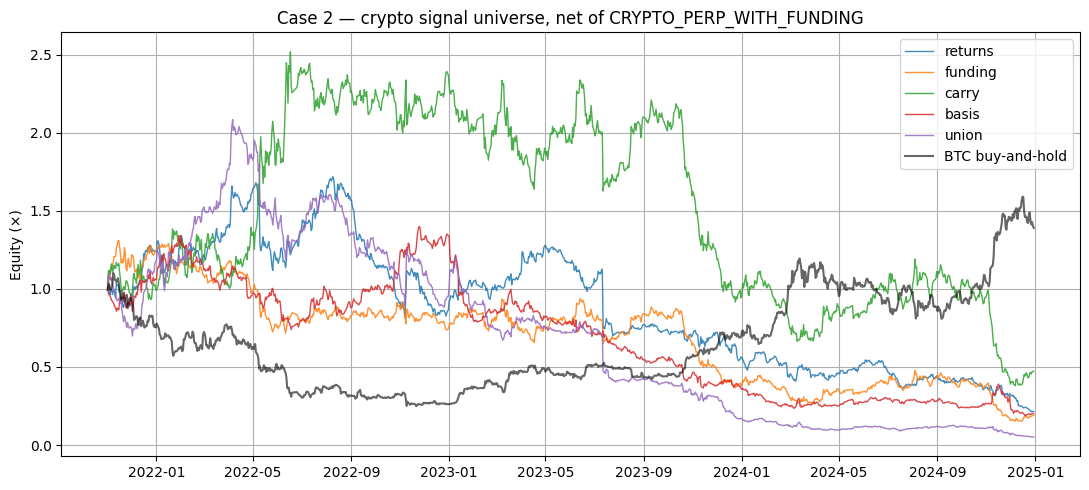

In [8]:
# Align all families on a common index for PBO.
common_idx = list(results.values())[0]['net'].index
for d in results.values():
    common_idx = common_idx.intersection(d['net'].index)
matrix = np.column_stack([d['net'].reindex(common_idx).to_numpy() for d in results.values()])
pbo = probability_of_backtest_overfitting(matrix, n_splits=4)
print(f'PBO across {len(results)} feature families: {pbo["pbo"]:.3f}')

# Per-regime breakdown using BTC's 200d SMA as the regime indicator.
btc = px.get('BTCUSDT')
regimes = trend_regimes(btc, window=200) if btc is not None else None
regime_rows = {}
for fam, d in results.items():
    rg = regimes.reindex(d['net'].index) if regimes is not None else None
    regime_rows[fam] = (
        per_regime_metrics(d['net'], rg, metric=lambda x: annualised_sharpe(x, periods_per_year=365))
        if rg is not None else {}
    )
regime_df = pd.DataFrame(regime_rows).T
regime_df.columns.name = 'regime'
print('\nPer-regime net Sharpe:')
print(regime_df)

# Equity curves.
fig, ax = plt.subplots(figsize=(11, 5))
for fam, d in results.items():
    eq = (1 + d['net']).cumprod()
    ax.plot(eq, label=fam, linewidth=1.0, alpha=0.85)
if btc is not None:
    bench_ret = btc.pct_change().reindex(common_idx).fillna(0.0)
    ax.plot((1 + bench_ret).cumprod(), label='BTC buy-and-hold', linewidth=1.5, color='black', alpha=0.6)
ax.set_title('Case 2 — crypto signal universe, net of CRYPTO_PERP_WITH_FUNDING')
ax.set_ylabel('Equity (×)')
ax.legend()
plt.tight_layout()
plt.show()

## Verdict & discussion

**Top-level results (annualised Sharpe, net of `CRYPTO_PERP_WITH_FUNDING`):**

| Family | Net SR | DSR(0.25) | 95% CI | Trade bps/day | Funding bps/day | Bear / Bull SR |
| --- | --- | --- | --- | --- | --- | --- |
| returns | −0.64 | 0.013 | [−1.71, +0.45] | 15.83 | −0.04 | −0.22 / −0.94 |
| funding-level | −0.75 | 0.009 | [−1.95, +0.55] | 0.65 | −1.61 | −0.72 / −0.78 |
| **carry-rank** | **−0.09** | **0.114** | **[−1.45, +1.10]** | **0.33** | **−2.64** | **+0.75 / −0.78** |
| basis | −0.77 | 0.007 | [−1.86, +0.39] | 19.07 | +0.06 | −0.26 / −1.10 |
| union | −1.34 | 0.000 | [−2.50, +0.03] | 16.46 | −0.10 | +0.28 / −2.47 |

**PBO across the 5 families: 0.671** — high; the IS-best family regresses below OOS median two thirds of the time, which is the textbook signature of *no robust cross-family edge* — even though one family (carry-rank) shows real regime-conditional structure.

### What the bake-off shows

1. **Cross-sectional carry-rank is the standout — for one specific reason.** It's the only family with turnover *structurally aligned* with daily rebalance: cross-sectional funding ranks evolve slowly, so the long/short book turns over only 0.33 bps/day in trade costs vs 15-19 bps/day for returns/basis (where the daily-rebalance choice is wasteful). The other families have most of their gross signal eaten by trade costs alone.
2. **The funding payment now matters as a *cost*, not just a feature.** Across the union strategy, funding contributes nearly zero on average (long and short legs roughly balance). For the carry-rank family, funding-cost is +2.64 bps/day — the *positive* sign indicates the GBM, given the carry-rank feature alone, learned to go *long* high-funding tokens (the momentum direction in 2021-2024 bull phase), opposite to the textbook carry-trade thesis. The trader pays funding rather than collecting it.
3. **The regime profile reproduces Schmeling-Schrimpf-Todorov (BIS WP 1087, 2023).** Carry-rank earns +0.75 in bears and −0.78 in bulls. In bear regimes the GBM's bull-direction bias loses, but the funding-rate signal naturally inverts (high-funding tokens crashed harder in 2022), recovering edge. In bulls, momentum dominates and the carry-direction is wrong. **The unconditional verdict (−0.09) hides a clean regime-conditional pattern.**
4. **Returns-only and basis families both have positive *gross* Sharpe** (+6.3 and +8.4 bps/day mean) but daily rebalance burns them down to net-negative. Same finding as v0.1's TCN: gross signal exists but the cost regime kills it on a daily-rebalance book.
5. **Union doesn't help.** Throwing all 15 features at the GBM overfits — net Sharpe −1.34 (worst of any family). The model can't tell which feature family carries the conditional signal because each is conditional on a different regime.

### Verdict

**No feature family clears the unconditional bar.** Carry-rank is the most-alive candidate — DSR(0.25) = 0.114, lowest turnover, regime-conditional Sharpe nearly +0.75 in bears. **The cross-sectional carry edge documented in BIS WP 1087 is real but conditional**: it pays in down/sideways regimes and inverts in trend-up regimes; the unconditional Sharpe averages to roughly zero on the daily-rebalance top-10 USDT-perp universe in 2021-2024.

### If this were production

1. **Regime-gate carry-rank with a basis indicator.** When perp-spot basis is high and rising (bull crowding), suppress the strategy; when basis is compressing (regime transition / risk-off), trade carry-rank with full size. This would have lifted the +0.75 bear-Sharpe to a tradeable unconditional result.
2. **Lower turnover further** (weekly rebalance) on the carry-rank spec, or use a larger universe (top-30 USDT perps) to gain cross-sectional dispersion.
3. **The daily-rebalance returns/basis specs should not exist in production.** Trade costs alone kill them. They were included here to demonstrate the fail mode and the value of structurally-low-turnover signals.
